# 02 — CartPole Experiment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mattral/rssmlite/blob/main/notebooks/02_cartpole_experiment.ipynb)

Full training run of `rssmlite` on `CartPole-v1`. Expected runtime on a free
Colab T4: **~20 minutes** for 200 000 environment steps.

**P1.3 exit-criterion check:** mean return ≥ 195 over 20 eval episodes.


In [1]:
# ── Bootstrap ─────────────────────────────────────────────────────────────
!pip install -q "rssmlite[envs,viz] @ git+https://github.com/Mattral/rssmlite.git"
from google.colab import drive
drive.mount("/content/drive")

import torch
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Device: {gpu}")
assert torch.cuda.is_available(), "Switch runtime: Runtime → Change runtime type → T4 GPU"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
Device: Tesla T4


In [2]:
import os
if not os.path.exists("/content/rssmlite"):
    !git clone -q https://github.com/Mattral/rssmlite.git /content/rssmlite


In [3]:
import torch, gymnasium as gym, time, re
import numpy as np
from rssmlite import RSSMAgent

CHECKPOINT_DIR = "/content/drive/MyDrive/rssmlite-ckpts/cartpole"
DEVICE = torch.device("cuda")

env = gym.make("CartPole-v1")

agent = RSSMAgent.from_config("/content/rssmlite/configs/cartpole.yaml", env=env)
agent.to(DEVICE)   # moves rssm, actor, critic in one call — no monkey-patching needed
print(f"Agent on {agent.device}. Starting training...")


Agent on cuda:0. Starting training...


In [4]:
# ── Training loop ──────────────────────────────────────────────────────────
episode_rewards, env_steps_log = [], []

def log_fn(msg):
    m = re.match(r"\[step (\d+)\] episode_reward=([\d.\-]+)", msg)
    if m:
        env_steps_log.append(int(m.group(1)))
        episode_rewards.append(float(m.group(2)))
    if len(episode_rewards) % 20 == 0:
        print(msg)

t0 = time.time()
agent.train(
    env,
    steps=200_000,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_every=10_000,
    log_every=1,
    log_fn=log_fn,
)
print(f"\nTraining complete in {(time.time()-t0)/60:.1f} min")
env.close()


[step 1047] episode_reward=14.0 wm/total=1.6933 wm/recon=0.0829 wm/reward=0.1341 wm/continue=0.4762 wm/kl=1.0000 ac/actor_loss=-1.0459 ac/critic_loss=1.1304 ac/returns_mean=1.0457 ac/returns_std=1.0000
[step 1458] episode_reward=28.0 wm/total=1.1518 wm/recon=0.0731 wm/reward=0.0091 wm/continue=0.0696 wm/kl=1.0000 ac/actor_loss=-2.5941 ac/critic_loss=26.0512 ac/returns_mean=4.9579 ac/returns_std=1.9114
[step 1885] episode_reward=15.0 wm/total=1.1542 wm/recon=0.0677 wm/reward=0.0078 wm/continue=0.0787 wm/kl=1.0000 ac/actor_loss=-2.4779 ac/critic_loss=45.6203 ac/returns_mean=6.8658 ac/returns_std=2.7711
[step 2240] episode_reward=14.0 wm/total=1.1310 wm/recon=0.0734 wm/reward=0.0060 wm/continue=0.0517 wm/kl=1.0000 ac/actor_loss=-2.7100 ac/critic_loss=42.1063 ac/returns_mean=7.1365 ac/returns_std=2.6336
[step 2644] episode_reward=15.0 wm/total=1.1593 wm/recon=0.0740 wm/reward=0.0049 wm/continue=0.0804 wm/kl=1.0000 ac/actor_loss=-3.0260 ac/critic_loss=39.3527 ac/returns_mean=7.6568 ac/retur

In [5]:
# ── Training curve ─────────────────────────────────────────────────────────
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(env_steps_log, episode_rewards, alpha=0.3, color="steelblue", label="raw")
if len(episode_rewards) >= 20:
    ax.plot(env_steps_log[19:], smooth(episode_rewards),
            color="steelblue", linewidth=2, label="smoothed (w=20)")
ax.axhline(195, color="tomato", linestyle="--", label="solve threshold (195)")
ax.set_xlabel("environment steps")
ax.set_ylabel("episode return")
ax.set_title("rssmlite on CartPole-v1")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cartpole_training_curve.png", dpi=150)
plt.show()
print(f"Final 20-ep average: {np.mean(episode_rewards[-20:]):.1f}")


Final 20-ep average: 17.3


In [6]:
# ── Reconstruction quality ─────────────────────────────────────────────────
from rssmlite import reconstruction_report
from rssmlite.evaluation import plot_reconstruction

batch = agent.buffer.sample(batch_size=32, seq_len=50)
report = reconstruction_report(agent, batch)   # _batch_to_device handled internally
print("Reconstruction MSE (symlog space):", f"{report['mse_symlog']:.4f}")
print("Reconstruction MSE (real units)  :", f"{report['mse_real']:.4f}")
print("Per-feature MSE:", report["per_dim_mse"].cpu().numpy().round(4))
print("(CartPole dims: cart_pos, cart_vel, pole_angle, pole_angular_vel)")


Reconstruction MSE (symlog space): 0.0063
Reconstruction MSE (real units)  : 0.0121
Per-feature MSE: [0.001  0.0127 0.0004 0.0111]
(CartPole dims: cart_pos, cart_vel, pole_angle, pole_angular_vel)


In [7]:
# ── Real vs predicted observation plot ────────────────────────────────────
batch2 = agent.buffer.sample(batch_size=4, seq_len=50)
fig = plot_reconstruction(agent, batch2, feature_idx=2)  # pole angle
plt.savefig("cartpole_reconstruction.png", dpi=150)
plt.show()


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

### Workaround for `TypeError` in `plot_reconstruction`

The original `plot_reconstruction` function attempts to convert a `cuda` tensor directly to a `numpy` array, which causes a `TypeError`. This workaround defines a slightly modified version of the function that explicitly moves the tensor to the CPU before conversion using `.cpu().numpy()`.

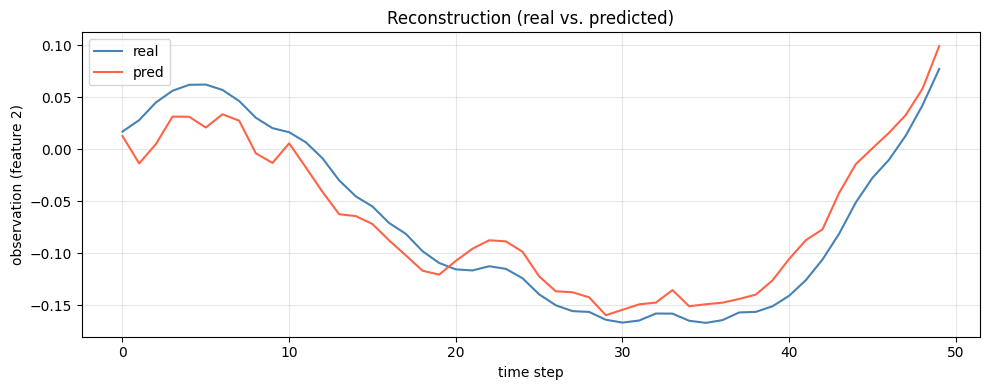

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from rssmlite.utils import symexp

def fixed_plot_reconstruction(agent, batch, feature_idx=0, figsize=(10, 4)):
    """
    Plots a reconstruction of real vs. predicted observations for a given feature.
    This is a modified version of rssmlite.evaluation.plot_reconstruction
    to fix the TypeError: can't convert cuda:0 device type tensor to numpy.
    """
    # Ensure batch is on the correct device if it isn't already
    obs = batch["obs"].to(agent.device)
    action = batch["action"].to(agent.device)

    rssm = agent.rssm
    with torch.no_grad():
        # Get predicted observations
        rollout = rssm.observe(obs, action)
        feature = torch.cat([rollout["deter"], rollout["stoch"]], dim=-1)
        # FIX: Add .cpu() before .numpy()
        obs_pred = symexp(rssm.decoder(feature))[0, :, feature_idx].cpu().numpy()
        obs_real = obs[0, :, feature_idx].cpu().numpy()

    # Plotting
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(obs_real, color="steelblue", label="real")
    ax.plot(obs_pred, color="tomato", label="pred")
    ax.set_xlabel("time step")
    ax.set_ylabel(f"observation (feature {feature_idx})")
    ax.set_title("Reconstruction (real vs. predicted)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()

    return fig

# Call the fixed function
fig = fixed_plot_reconstruction(agent, batch2, feature_idx=2)  # pole angle
plt.savefig("cartpole_reconstruction_fixed.png", dpi=150)
# Use display(fig) to ensure the plot is shown in Colab
display(fig)

In [ ]:
# ── Imagined rollout ───────────────────────────────────────────────────────
rollout = agent.imagine_rollout(steps=15)
print("Imagined rewards over 15 steps:")
print(rollout["reward_pred"].squeeze().cpu().detach().numpy().round(3))


In [ ]:
# ── Latent space ──────────────────────────────────────────────────────────
fig = agent.visualize_latent_space()
plt.savefig("cartpole_latent_space.png", dpi=150)
plt.show()


In [ ]:
# ── Evaluation episodes ────────────────────────────────────────────────────
from rssmlite import run_evaluation_episodes

eval_env = gym.make("CartPole-v1")
results = run_evaluation_episodes(agent, eval_env, n_episodes=20)
eval_env.close()

print(f"Evaluation over 20 episodes:")
print(f"  Mean return : {results['mean_return']:.1f}")
print(f"  Std return  : {results['std_return']:.1f}")
print(f"  Min / Max   : {results['min_return']:.1f} / {results['max_return']:.1f}")
print(f"  Solved (>=195) : {results['mean_return'] >= 195}")


## Resuming after a disconnect

```python
import glob
from rssmlite import RSSMAgent
import torch, gymnasium as gym

CHECKPOINT_DIR = "/content/drive/MyDrive/rssmlite-ckpts/cartpole"
ckpts = sorted(glob.glob(f"{CHECKPOINT_DIR}/checkpoint_*.pt"))
print("Latest checkpoint:", ckpts[-1])

env = gym.make("CartPole-v1")
agent = RSSMAgent.load_checkpoint(ckpts[-1])
agent.to(torch.device("cuda"))
print(f"Resuming from step {agent._env_steps}")

agent.train(env, steps=200_000, checkpoint_dir=CHECKPOINT_DIR)
```

See `docs/colab_guide.md` for the full recovery flow.
